# predictive_maintenance

参考资料：
https://www.kaggle.com/datasets/shivamb/machine-predictive-maintenance-classification

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.pyplot import imshow
from tqdm import tqdm
from ipywidgets import IntProgress
import time 


In [25]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [26]:
path = "predictive_maintenance.csv"
df = pd.read_csv(path)
print(df.shape)                   # (10000, 10)
df.head()

(10000, 10)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [27]:
numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]
categorical_features = ["Type"]

X = df[numeric_features + categorical_features]
y = df['Target']
# 类别分布很不均衡，先看一下
y.value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

In [28]:
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type
0,298.1,308.6,1551,42.8,0,M
1,298.2,308.7,1408,46.3,3,L
2,298.1,308.5,1498,49.4,5,L
3,298.2,308.6,1433,39.5,7,L
4,298.2,308.7,1408,40.0,9,L


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y, # 分层抽样，保持各类比例
)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)
print("训练集故障比例:", f"{y_train.mean():.2%}")
print("测试集故障比例:", f"{y_test.mean():.2%}")

训练集: (7000, 6)
测试集: (3000, 6)
训练集故障比例: 3.39%
测试集故障比例: 3.40%


## KNN

In [30]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [31]:
knn = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance")),
    ]
)

knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [32]:
y_pred = knn.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["正常", "故障"], digits=3))

              precision    recall  f1-score   support

          正常      0.976     0.996     0.986      2898
          故障      0.711     0.314     0.435       102

    accuracy                          0.972      3000
   macro avg      0.844     0.655     0.711      3000
weighted avg      0.967     0.972     0.967      3000



/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25925 (\N{CJK UNIFIED IDEOGRAPH-6545}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38556 (\N{CJK UNIFIED IDEOGRAPH-969C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/p

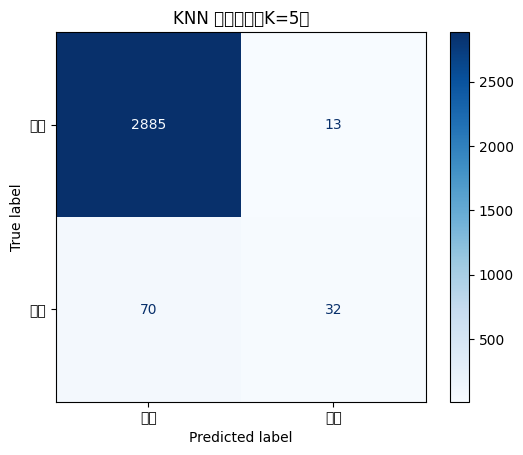

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["正常", "故障"],
    cmap="Blues",
    values_format="d",
)
plt.title("KNN 混淆矩阵（K=5）")
plt.show()

In [34]:
k_values = [1, 3, 5, 7, 9, 15, 21, 31]
rows = []

for k in k_values:
    model = Pipeline(
        steps=[
            ("prep", preprocessor),
            ("model", KNeighborsClassifier(n_neighbors=k, weights="distance")),
        ]
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    rows.append(
        {
            "k": k,
            "accuracy": model.score(X_test, y_test),
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred),
            "f1": f1_score(y_test, pred, zero_division=0),
        }
    )

k_results = pd.DataFrame(rows)
k_results

,k,accuracy,precision,recall,f1
0,1,0.962667,0.439024,0.352941,0.391304
1,3,0.970000,0.590909,0.382353,0.464286
2,5,0.972333,0.711111,0.313725,0.435374
3,7,0.972667,0.763158,0.284314,0.414286
4,9,0.970667,0.733333,0.215686,0.333333
5,15,0.971667,0.869565,0.196078,0.320000
6,21,0.970667,0.888889,0.156863,0.266667
7,31,0.969667,0.866667,0.127451,0.222222


/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19979 (\N{CJK UNIFIED IDEOGRAPH-4E0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ahao/miniconda3/envs/ml-industrial/lib/python3.11/site-packages/IPython/core/p

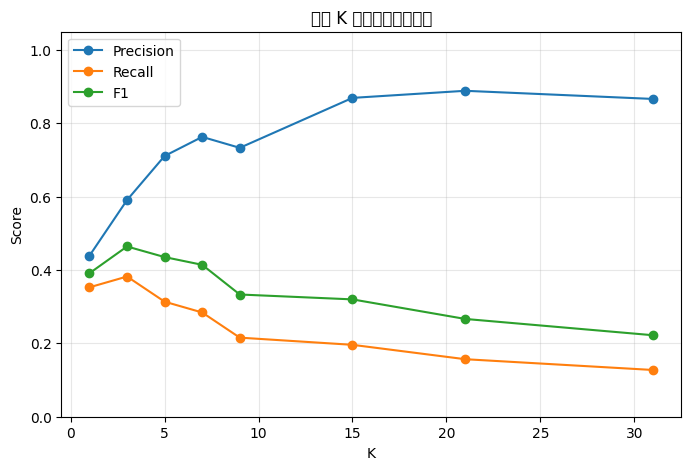

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(k_results["k"], k_results["precision"], marker="o", label="Precision")
plt.plot(k_results["k"], k_results["recall"], marker="o", label="Recall")
plt.plot(k_results["k"], k_results["f1"], marker="o", label="F1")
plt.xlabel("K")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.title("不同 K 值下的测试集表现")
plt.show()

In [36]:
best_k = int(k_results.sort_values("f1", ascending=False).iloc[0]["k"])
best_f1 = k_results["f1"].max()

print(f"按 F1 选择的 K: {best_k}")
print(f"对应 F1: {best_f1:.3f}")

按 F1 选择的 K: 3
对应 F1: 0.464


## SVM支持向量机

In [37]:
svm_linear = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("svm", SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=42)),
    ]
)

svm_linear.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]', 'Torque [Nm]','Tool wear [min]','Type']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``

In [38]:
y_pred_svm_linear = svm_linear.predict(X_test)
print(classification_report(y_test, y_pred_svm_linear))

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      2898
           1       0.15      0.78      0.25       102

    accuracy                           0.84      3000
   macro avg       0.57      0.81      0.58      3000
weighted avg       0.96      0.84      0.89      3000



In [39]:
# 高斯 RBF 核（SVC 的默认核），拟合能力通常比线性核更强
svm_rbf = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("svm", SVC(class_weight="balanced", random_state=42)),
    ]
)

svm_rbf.fit(X_train, y_train)

y_pred_svm_rbf = svm_rbf.predict(X_test)
print(classification_report(y_test, y_pred_svm_rbf))


              precision    recall  f1-score   support

           0       1.00      0.92      0.96      2898
           1       0.29      0.92      0.44       102

    accuracy                           0.92      3000
   macro avg       0.64      0.92      0.70      3000
weighted avg       0.97      0.92      0.94      3000



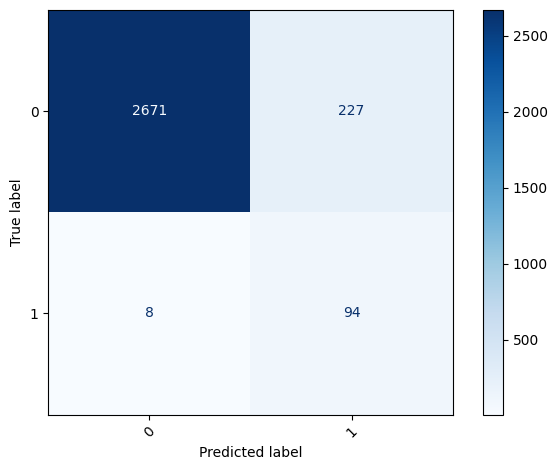

In [40]:
ConfusionMatrixDisplay.from_estimator(
    svm_rbf, X_test, y_test, xticks_rotation=45, cmap="Blues"
)
plt.tight_layout()
plt.show()
